In [1]:
import os
os.chdir('../')

In [2]:
import torch
import torch.nn as nn

c:\Users\jajua\miniconda3\envs\variational-ip\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MNIST/KMNIST/FashionMNIST

In [3]:
from arch.mnist import ClassifierMNIST, QuerierMNIST

In [4]:
# MNIST
ckpt = torch.load('./pretrain/mnist.pth', map_location='cpu')

classifier = ClassifierMNIST()
classifier = nn.DataParallel(classifier)
classifier.load_state_dict(ckpt['classifier'])

querier = QuerierMNIST(num_classes=676, tau=0.2)
querier = nn.DataParallel(querier)
querier.load_state_dict(ckpt['querier'])

<All keys matched successfully>

# Testing the Pretrained Model


Label: 7
Shape: torch.Size([1, 28, 28])


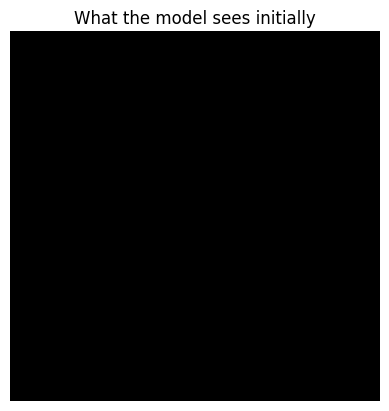

In [11]:
# Prepping models for evaluation
classifier.eval()
querier.eval()

#Importing Library
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

#Prepping the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

image, label = test_dataset[0]

print("Label:", label)
print("Shape:", image.shape)

#Visualizing the image
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off");

#Creating mask image
masked_image = torch.zeros_like(image)
plt.imshow(masked_image.squeeze(), cmap="gray")
plt.title("What the model sees initially")
plt.axis("off");

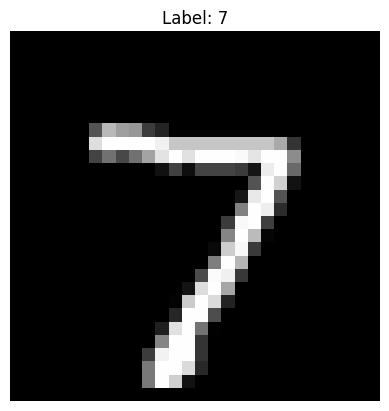

In [12]:
#Visualizing the image
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off");


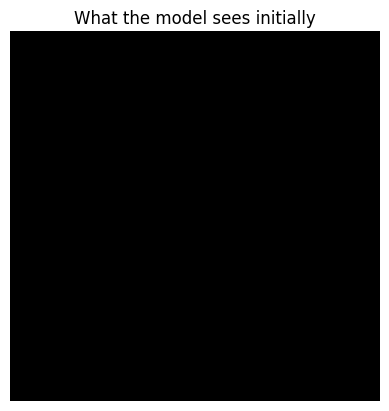

In [13]:
#Creating mask image (what the model sees initially)
masked_image = torch.zeros_like(image)
plt.imshow(masked_image.squeeze(), cmap="gray")
plt.title("What the model sees initially")
plt.axis("off");

In [14]:
# Create a mask that keeps track of which 3x3 patches of the original image have been revealed to the model.
#
# There are 26 possible vertical starting positions and
# 26 possible horizontal starting positions for a 3x3 patch
# inside a 28x28 MNIST image.
#
# Therefore, there are 26 * 26 = 676 possible patches.

query_mask = torch.zeros(1, 26, 26)

# Check that the mask has the expected dimensions.
print(query_mask.shape)

torch.Size([1, 26, 26])


In [16]:
# ============================================================
# STEP 6: ASK THE QUERIER WHICH PATCH TO REVEAL FIRST
# ============================================================

# The querier works with 676 possible patches.
# Although we conceptually think of these as a 26 x 26 grid,
# the network represents them as a single vector of length 676.
#
# So we flatten our 26 x 26 query mask.

model_query_mask = query_mask.reshape(1, 676)

# Add a batch dimension to the image.
# masked_image: [1, 28, 28]
# model_image:  [1, 1, 28, 28]

model_image = masked_image.unsqueeze(0)

# Ask the pretrained querier which patch it wants to examine.
# We use no_grad() because we're only running the model,
# not training it.

with torch.no_grad():
    query_scores = querier(model_image, model_query_mask)

# There should now be one score for each of the 676 possible
# 3x3 patches.

print("Query scores shape:", query_scores.shape)

Query scores shape: torch.Size([1, 676])


In [17]:
# ============================================================
# STEP 7: FIND THE QUERIER'S FIRST CHOICE
# ============================================================

# Find the index with the highest score.
# This is the patch that the trained querier considers most
# useful to inspect first.

query_index = query_scores.argmax(dim=1).item()

print("Chosen patch index:", query_index)

# Convert the single index (0–675) back into a 26 x 26
# row/column position.
#
# For example:
#   index 0   -> row 0, column 0
#   index 1   -> row 0, column 1
#   index 26  -> row 1, column 0

query_row = query_index // 26
query_col = query_index % 26

print("Patch starts at row:", query_row)
print("Patch starts at column:", query_col)

Chosen patch index: 374
Patch starts at row: 14
Patch starts at column: 10


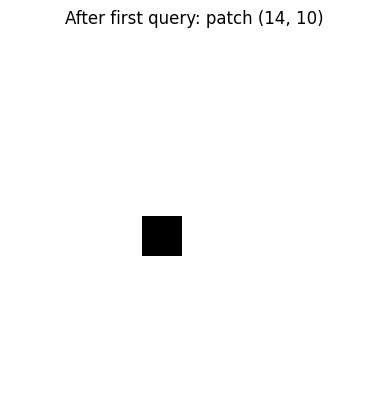

In [18]:
# ============================================================
# STEP 8: REVEAL THE FIRST 3x3 PATCH
# ============================================================

# The querier selected a patch whose top-left corner is:
#   (query_row, query_col)
#
# We now copy that 3x3 region from the REAL image into the
# previously blank masked image.

masked_image[
    :,
    query_row:query_row + 3,
    query_col:query_col + 3
] = image[
    :,
    query_row:query_row + 3,
    query_col:query_col + 3
]

# Mark this patch as "queried" in our 26 x 26 mask.
query_mask[0, query_row, query_col] = 1

# ------------------------------------------------------------
# Display what the model can see after its FIRST query.
# ------------------------------------------------------------

plt.imshow(masked_image.squeeze(), cmap="gray")
plt.title(
    f"After first query: patch ({query_row}, {query_col})"
)
plt.axis("off");

In [19]:
# ============================================================
# STEP 9: CLASSIFY THE PARTIALLY REVEALED IMAGE
# ============================================================

# The classifier expects an image with a batch dimension.
# Our masked image is currently [1, 28, 28].
# Add the batch dimension -> [1, 1, 28, 28].

model_image = masked_image.unsqueeze(0)

# Run the classifier.
# Since we're only evaluating the pretrained model, we don't
# need to calculate gradients.

with torch.no_grad():
    logits = classifier(model_image)

# The classifier produces 10 numbers:
# one score for each possible digit (0 through 9).

print("Classifier output shape:", logits.shape)

# Convert the scores into probabilities.
probabilities = torch.softmax(logits, dim=1)

# Find the digit with the highest probability.
prediction = probabilities.argmax(dim=1).item()

# Get the probability assigned to that digit.
confidence = probabilities[0, prediction].item()

print("Predicted digit:", prediction)
print("Confidence:", confidence)
print("True digit:", label)

Classifier output shape: torch.Size([1, 10])
Predicted digit: 7
Confidence: 0.3520154356956482
True digit: 7


In [20]:
# ============================================================
# STEP 10: ASK THE QUERIER FOR THE SECOND PATCH
# ============================================================

# The masked image now contains the first 3x3 patch.
# The query mask also records that this patch has already
# been examined.

model_image = masked_image.unsqueeze(0)

# Flatten the 26 x 26 query mask into the 676-dimensional
# representation expected by the querier.

model_query_mask = query_mask.reshape(1, 676)

# Ask the trained querier which patch would be most useful next.

with torch.no_grad():
    query_scores = querier(model_image, model_query_mask)

# Find the patch with the highest score.
query_index = query_scores.argmax(dim=1).item()

# Convert the index back into its 26 x 26 row/column location.

query_row = query_index // 26
query_col = query_index % 26

print("Second patch index:", query_index)
print("Second patch starts at row:", query_row)
print("Second patch starts at column:", query_col)

Second patch index: 352
Second patch starts at row: 13
Second patch starts at column: 14


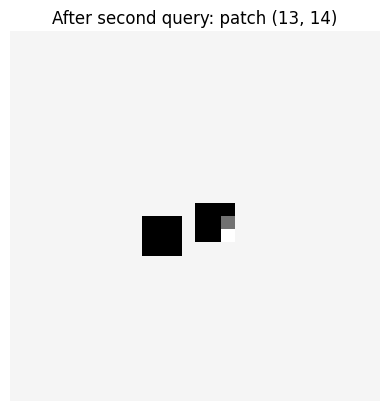

In [21]:
# ============================================================
# STEP 11: REVEAL THE SECOND 3x3 PATCH
# ============================================================

# Copy the second patch from the REAL MNIST image into the
# partially revealed image.

masked_image[
    :,
    query_row:query_row + 3,
    query_col:query_col + 3
] = image[
    :,
    query_row:query_row + 3,
    query_col:query_col + 3
]

# Mark this patch as already queried.
query_mask[0, query_row, query_col] = 1

# Display what the model can now see.

plt.imshow(masked_image.squeeze(), cmap="gray")
plt.title(
    f"After second query: patch ({query_row}, {query_col})"
)
plt.axis("off");

In [22]:
# ============================================================
# STEP 12: CLASSIFY THE IMAGE AFTER TWO QUERIES
# ============================================================

# Add the batch dimension required by the classifier.

model_image = masked_image.unsqueeze(0)

# Ask the classifier to identify the digit using everything
# it has seen so far.

with torch.no_grad():
    logits = classifier(model_image)

# Convert the classifier's raw scores into probabilities.

probabilities = torch.softmax(logits, dim=1)

# Find the digit with the highest probability.

prediction = probabilities.argmax(dim=1).item()

# Get the probability assigned to that prediction.

confidence = probabilities[0, prediction].item()

print("Predicted digit:", prediction)
print("Confidence:", confidence)
print("True digit:", label)

Predicted digit: 7
Confidence: 0.425704687833786
True digit: 7



Query 3
  Patch location: (20, 8)
  Prediction:     7
  Confidence:     0.805
  True digit:     7


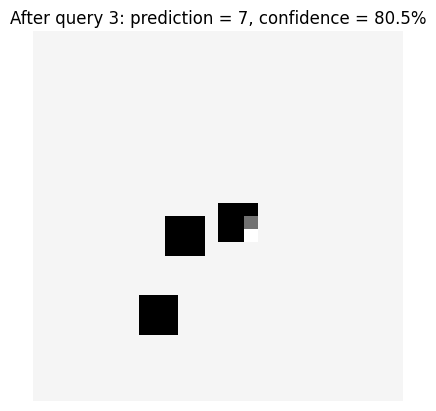


Query 4
  Patch location: (16, 14)
  Prediction:     7
  Confidence:     0.944
  True digit:     7


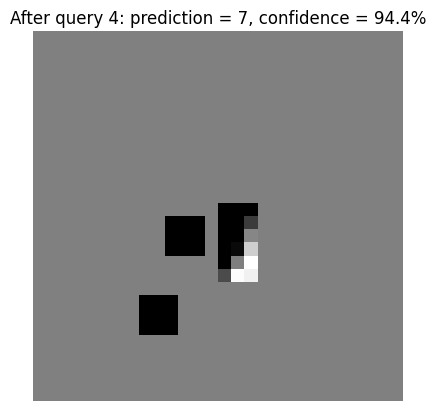


Query 5
  Patch location: (7, 14)
  Prediction:     7
  Confidence:     0.998
  True digit:     7


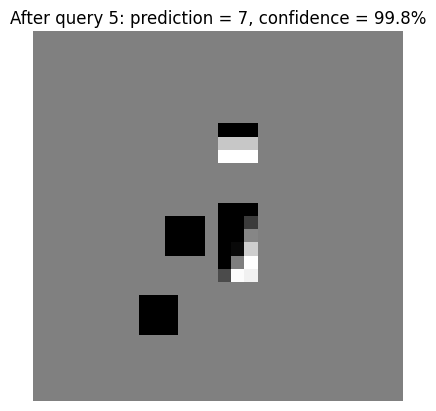

In [23]:
# ============================================================
# STEPS 13–15: QUERIES 3, 4, AND 5
# ============================================================

for query_number in range(3, 6):

    # --------------------------------------------------------
    # 1. Give the current partially revealed image and query
    #    history to the querier.
    # --------------------------------------------------------

    model_image = masked_image.unsqueeze(0)
    model_query_mask = query_mask.reshape(1, 676)

    with torch.no_grad():
        query_scores = querier(model_image, model_query_mask)

    # --------------------------------------------------------
    # 2. Find the patch the querier wants to inspect next.
    # --------------------------------------------------------

    query_index = query_scores.argmax(dim=1).item()

    query_row = query_index // 26
    query_col = query_index % 26

    # --------------------------------------------------------
    # 3. Reveal that 3x3 patch from the ORIGINAL image.
    # --------------------------------------------------------

    masked_image[
        :,
        query_row:query_row + 3,
        query_col:query_col + 3
    ] = image[
        :,
        query_row:query_row + 3,
        query_col:query_col + 3
    ]

    # Record that this patch has now been queried.
    query_mask[0, query_row, query_col] = 1

    # --------------------------------------------------------
    # 4. Ask the classifier to identify the digit using
    #    everything revealed so far.
    # --------------------------------------------------------

    model_image = masked_image.unsqueeze(0)

    with torch.no_grad():
        logits = classifier(model_image)

    probabilities = torch.softmax(logits, dim=1)

    prediction = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, prediction].item()

    # --------------------------------------------------------
    # 5. Print what happened during this query.
    # --------------------------------------------------------

    print(f"\nQuery {query_number}")
    print(f"  Patch location: ({query_row}, {query_col})")
    print(f"  Prediction:     {prediction}")
    print(f"  Confidence:     {confidence:.3f}")
    print(f"  True digit:     {label}")

    # --------------------------------------------------------
    # 6. Display the image after this query.
    # --------------------------------------------------------

    plt.figure()
    plt.imshow(masked_image.squeeze(), cmap="gray")
    plt.title(
        f"After query {query_number}: "
        f"prediction = {prediction}, "
        f"confidence = {confidence:.1%}"
    )
    plt.axis("off")
    plt.show()

Observation 1: true digit = 2, queries = 7, final prediction = 2, final confidence = 96.6%
Observation 2: true digit = 1, queries = 2, final prediction = 1, final confidence = 94.3%
Observation 3: true digit = 0, queries = 3, final prediction = 0, final confidence = 89.9%


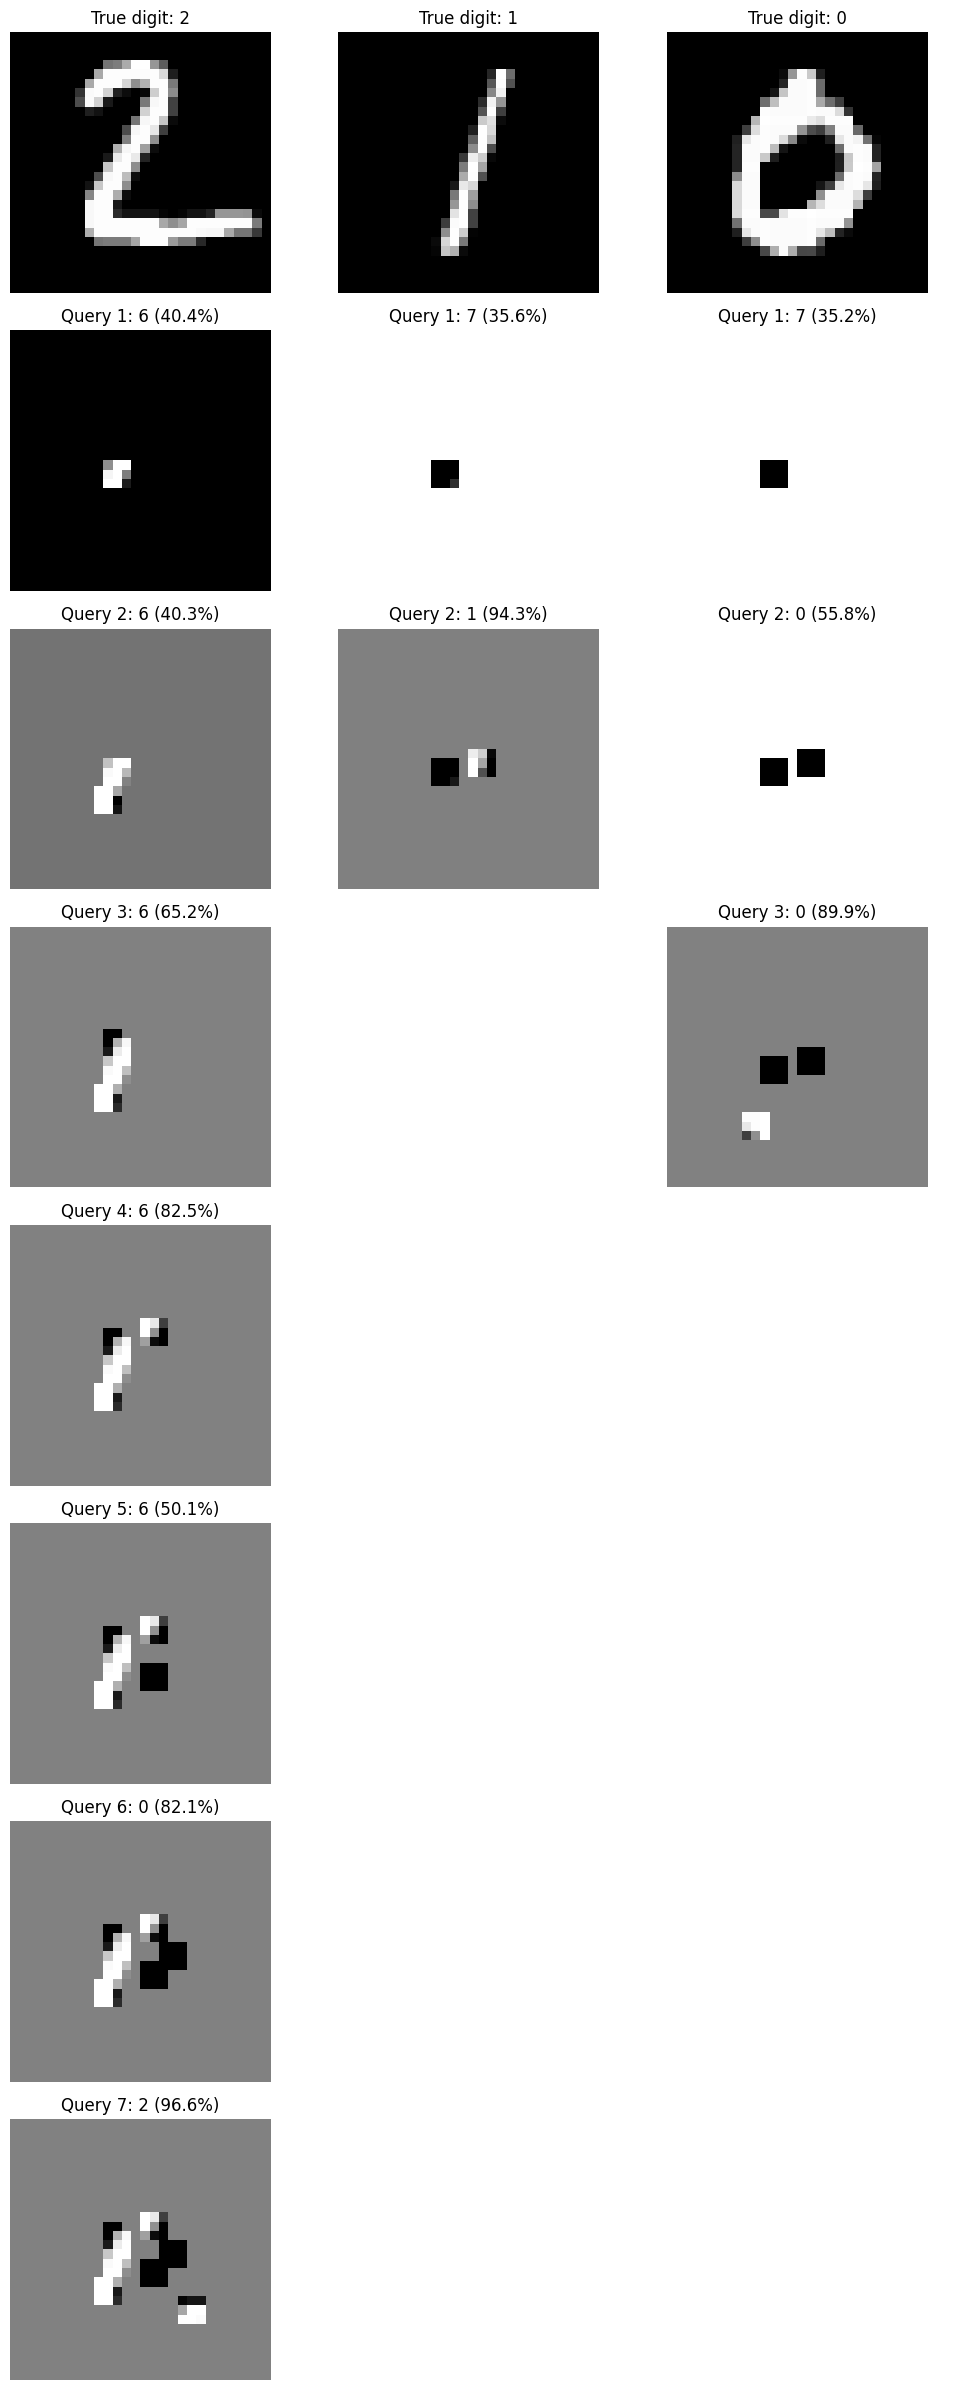

In [24]:
# ============================================================
# INFORMATION PURSUIT ON THE NEXT 3 MNIST TEST IMAGES
#
# For each image:
#   1. Start with nothing revealed.
#   2. Let the querier choose a 3x3 patch.
#   3. Reveal that patch.
#   4. Classify the partially revealed image.
#   5. Repeat until confidence > 85%.
#
# The resulting figure shows:
#
#       TRUE IMAGE
#           ↓
#       QUERY 1
#           ↓
#       QUERY 2
#           ↓
#          ...
# ============================================================

import math

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

CONFIDENCE_THRESHOLD = 0.85
MAX_QUERIES = 20

# We will examine the next 3 observations in the test set.
observation_indices = [1, 2, 3]


# ------------------------------------------------------------
# Store the results for each observation.
# ------------------------------------------------------------

all_results = []


# ============================================================
# PROCESS EACH OF THE 3 TEST IMAGES
# ============================================================

for observation_index in observation_indices:

    # --------------------------------------------------------
    # Get a fresh MNIST test image.
    # --------------------------------------------------------

    image, label = test_dataset[observation_index]

    # Make sure the image is a single tensor of shape:
    # [1, 28, 28]

    image = image.clone()

    # --------------------------------------------------------
    # Start with a completely hidden image.
    # --------------------------------------------------------

    masked_image = torch.zeros_like(image)

    # --------------------------------------------------------
    # Keep track of which patch locations have already
    # been queried.
    #
    # There are 26 x 26 = 676 possible 3x3 patches.
    # --------------------------------------------------------

    query_mask = torch.zeros(1, 26, 26)

    # --------------------------------------------------------
    # Save every stage of the partially revealed image.
    #
    # The first entry is the completely hidden image.
    # --------------------------------------------------------

    image_evolution = [masked_image.clone()]
    predictions = []
    confidences = []
    patch_locations = []

    # --------------------------------------------------------
    # Sequentially acquire information.
    # --------------------------------------------------------

    for query_number in range(1, MAX_QUERIES + 1):

        # ====================================================
        # A. ASK THE QUERIER WHICH PATCH TO LOOK AT NEXT
        # ====================================================

        model_image = masked_image.unsqueeze(0)

        # The querier expects the 26 x 26 mask flattened into
        # a vector containing 676 possible patch locations.

        model_query_mask = query_mask.reshape(1, 676)

        with torch.no_grad():
            query_scores = querier(
                model_image,
                model_query_mask
            )

        # Choose the patch with the highest score.

        query_index = query_scores.argmax(dim=1).item()

        # Convert the 676-index into a 26 x 26 location.

        query_row = query_index // 26
        query_col = query_index % 26

        patch_locations.append((query_row, query_col))


        # ====================================================
        # B. REVEAL THE CHOSEN 3x3 PATCH
        # ====================================================

        masked_image[
            :,
            query_row:query_row + 3,
            query_col:query_col + 3
        ] = image[
            :,
            query_row:query_row + 3,
            query_col:query_col + 3
        ]

        # Tell the querier that this location has now
        # been examined.

        query_mask[0, query_row, query_col] = 1


        # ====================================================
        # C. CLASSIFY THE PARTIALLY REVEALED IMAGE
        # ====================================================

        model_image = masked_image.unsqueeze(0)

        with torch.no_grad():
            logits = classifier(model_image)

        probabilities = torch.softmax(logits, dim=1)

        prediction = probabilities.argmax(dim=1).item()

        confidence = probabilities[
            0, prediction
        ].item()

        predictions.append(prediction)
        confidences.append(confidence)

        # Save the current state of the image so we can
        # display its evolution later.

        image_evolution.append(masked_image.clone())


        # ====================================================
        # D. STOP WHEN CONFIDENCE EXCEEDS 85%
        # ====================================================

        if confidence >= CONFIDENCE_THRESHOLD:
            break


    # --------------------------------------------------------
    # Save everything from this observation.
    # --------------------------------------------------------

    all_results.append({
        "image": image,
        "label": label,
        "evolution": image_evolution,
        "predictions": predictions,
        "confidences": confidences,
        "patch_locations": patch_locations
    })

    print(
        f"Observation {observation_index}: "
        f"true digit = {label}, "
        f"queries = {len(predictions)}, "
        f"final prediction = {predictions[-1]}, "
        f"final confidence = {confidences[-1]:.1%}"
    )


# ============================================================
# CREATE THE VISUALIZATION
# ============================================================

# Find the largest number of queries required by any of
# the three observations.

max_steps = max(
    len(result["evolution"])
    for result in all_results
)

# We need:
#   1 row for the true images
#   + rows for the query evolution

fig, axes = plt.subplots(
    max_steps,
    3,
    figsize=(10, 3 * max_steps)
)

# If matplotlib gives us a 1-dimensional array when there
# aren't many rows, convert it into a consistent 2D array.

if max_steps == 1:
    axes = axes.reshape(1, 3)


# ============================================================
# PLOT EACH OBSERVATION
# ============================================================

for column, result in enumerate(all_results):

    true_image = result["image"]
    label = result["label"]
    evolution = result["evolution"]
    predictions = result["predictions"]
    confidences = result["confidences"]

    # --------------------------------------------------------
    # TOP ROW: TRUE IMAGE
    # --------------------------------------------------------

    axes[0, column].imshow(
        true_image.squeeze(),
        cmap="gray"
    )

    axes[0, column].set_title(
        f"True digit: {label}"
    )

    axes[0, column].axis("off")


    # --------------------------------------------------------
    # REMAINING ROWS: INFORMATION PURSUIT EVOLUTION
    # --------------------------------------------------------

    for step in range(1, max_steps):

        ax = axes[step, column]

        # If this observation reached 85% before this step,
        # there is nothing more to display.

        if step >= len(evolution):
            ax.axis("off")
            continue

        # Display the partially revealed image.

        ax.imshow(
            evolution[step].squeeze(),
            cmap="gray"
        )

        prediction = predictions[step - 1]
        confidence = confidences[step - 1]

        ax.set_title(
            f"Query {step}: "
            f"{prediction} "
            f"({confidence:.1%})"
        )

        ax.axis("off")


# ------------------------------------------------------------
# Add labels above each column.
# ------------------------------------------------------------

for column, observation_index in enumerate(observation_indices):

    axes[0, column].set_xlabel(
        f"Test observation {observation_index}",
        fontsize=12
    )


plt.tight_layout()
plt.show()

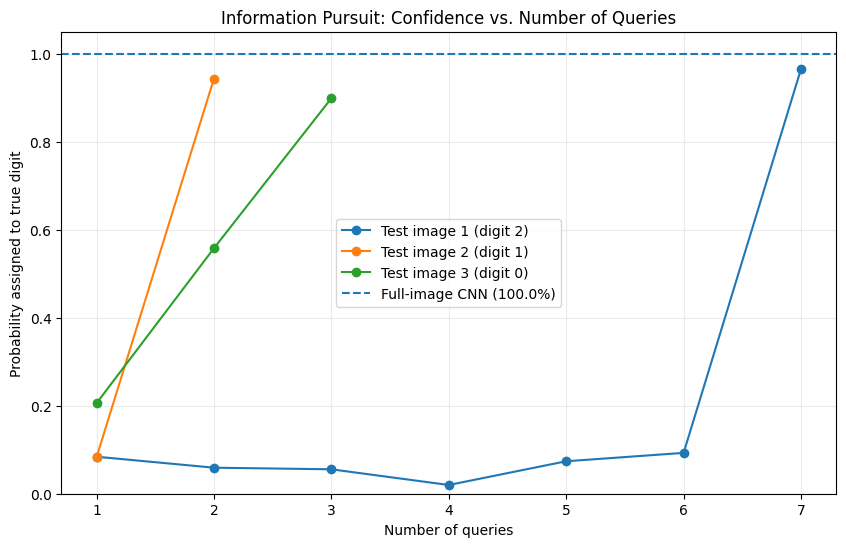

In [25]:
# ============================================================
# PLOT 1: CONFIDENCE IN THE TRUE DIGIT VS. NUMBER OF QUERIES
# ============================================================

plt.figure(figsize=(10, 6))

for i, result in enumerate(all_results):

    # Probability assigned to the TRUE digit after each query
    true_label = result["label"]

    true_class_confidence = []

    # Re-run the classifier on each stage so that we can
    # specifically extract P(True digit).
    for partial_image in result["evolution"][1:]:

        with torch.no_grad():
            logits = classifier(partial_image.unsqueeze(0))

        probabilities = torch.softmax(logits, dim=1)

        # Probability assigned specifically to the true class
        confidence = probabilities[0, true_label].item()

        true_class_confidence.append(confidence)

    # Queries are 1, 2, 3, ...
    queries = range(1, len(true_class_confidence) + 1)

    plt.plot(
        queries,
        true_class_confidence,
        marker="o",
        label=f"Test image {i+1} (digit {true_label})"
    )


# ------------------------------------------------------------
# Full-image CNN benchmark
# ------------------------------------------------------------

full_image_confidences = []

for result in all_results:

    image = result["image"]
    label = result["label"]

    with torch.no_grad():
        logits = classifier(image.unsqueeze(0))

    probabilities = torch.softmax(logits, dim=1)

    # Probability the full-image CNN assigns to the true digit
    full_image_confidences.append(
        probabilities[0, label].item()
    )

# Average full-image confidence across the 3 images
average_full_image_confidence = sum(
    full_image_confidences
) / len(full_image_confidences)


# Dashed horizontal line = full-image CNN performance
plt.axhline(
    average_full_image_confidence,
    linestyle="--",
    label=(
        f"Full-image CNN "
        f"({average_full_image_confidence:.1%})"
    )
)

plt.xlabel("Number of queries")
plt.ylabel("Probability assigned to true digit")
plt.title("Information Pursuit: Confidence vs. Number of Queries")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

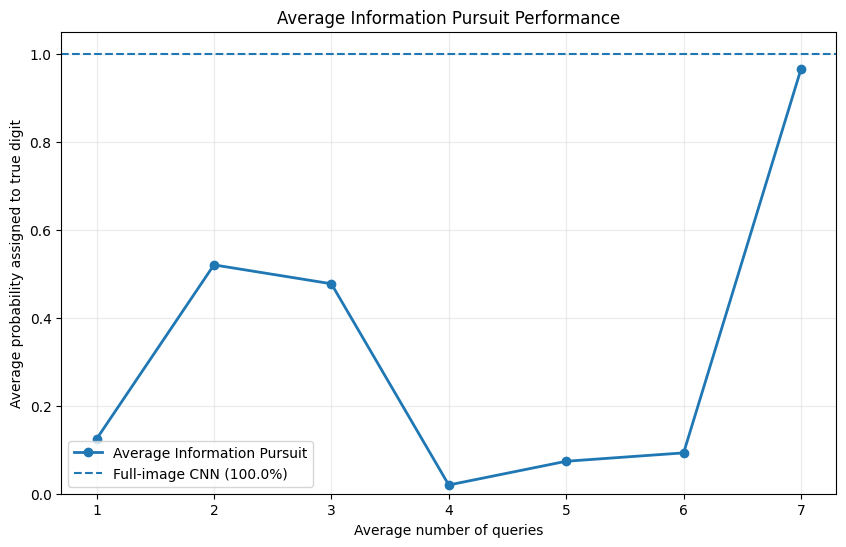

In [26]:
# ============================================================
# PLOT 2: AVERAGE CONFIDENCE VS. AVERAGE NUMBER OF QUERIES
# ============================================================

# Find the largest number of queries among the 3 images.
max_queries = max(
    len(result["confidences"])
    for result in all_results
)

average_confidence = []
average_queries = []

for query_number in range(1, max_queries + 1):

    values = []

    for result in all_results:

        # Only include an image if it required at least
        # this many queries.
        if len(result["confidences"]) >= query_number:

            # Recalculate the probability assigned to the
            # TRUE class at this query.
            partial_image = result["evolution"][query_number]

            with torch.no_grad():
                logits = classifier(
                    partial_image.unsqueeze(0)
                )

            probabilities = torch.softmax(logits, dim=1)

            true_label = result["label"]

            values.append(
                probabilities[0, true_label].item()
            )

    # Average confidence across the images that reached
    # this number of queries.
    if len(values) > 0:

        average_confidence.append(
            sum(values) / len(values)
        )

        average_queries.append(query_number)


# ------------------------------------------------------------
# Plot the average trajectory
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    average_queries,
    average_confidence,
    marker="o",
    linewidth=2,
    label="Average Information Pursuit"
)

# Average full-image CNN confidence
plt.axhline(
    average_full_image_confidence,
    linestyle="--",
    label=(
        f"Full-image CNN "
        f"({average_full_image_confidence:.1%})"
    )
)

plt.xlabel("Average number of queries")
plt.ylabel("Average probability assigned to true digit")
plt.title(
    "Average Information Pursuit Performance"
)
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()